# Ejemplos de como utilizar NumPy

In [2]:
# -------------------------------------------------------------------------
# 0) Versión de Numpy
# -------------------------------------------------------------------------
import numpy as np
print("Versión de NumPy:", np.__version__)

# -------------------------------------------------------------------------
# 1) Crear arreglos
# -------------------------------------------------------------------------

# 1.1 Listas
a = np.array([1, 2, 3, 4])
b = np.array([[1, 2], [3, 4]])

# 1.2 Arreglos comunes
z = np.zeros((2, 3))
o = np.ones((2, 3))
e = np.empty((2, 3))
I = np.eye(4)
c = np.full((2, 3), 7)


# 1.3 Rangos
r1 = np.arange(0, 10, 2)        # 0,2,4,6,8
r2 = np.linspace(0, 1, 5)

# -------------------------------------------------------------------------
# 2) Indexación y slicing
# -------------------------------------------------------------------------

# 2.1 1D
x = np.array([10, 20, 30, 40, 50])
print("x[0] =", x[0])
print("x[-1] =", x[-1])
print("x[1:4] =", x[1:4])
print("x[::2] =", x[::2], "\n")

# 2.2 2D
M = np.arange(1, 13).reshape(3, 4)
print("M[0,0] =", M[0, 0])
print("M[:,1] (col 1) =", M[:, 1])
print("M[1,:] (fila 1) =", M[1, :])
print("M[0:2,1:3] (submatriz) =\n", M[0:2, 1:3], "\n")

# 2.3 OJO: slicing devuelve vista (no copia) si se puede
A = np.arange(10)
v = A[2:6]          # normalmente es vista
v[:] = 999          # modifica también A

A = np.arange(10)
copia = A[2:6].copy()
copia[:] = 999      # NO modifica A

# -------------------------------------------------------------------------
# 3) Tipos (dtype)
# -------------------------------------------------------------------------

a32 = np.array([1, 2, 3], dtype=np.int32)
b64 = np.array([1, 2, 3], dtype=np.float64)

xf = np.array([1.2, 2.8, 3.1])
print("xf.astype(int32) (trunca) =", xf.astype(np.int32), "\n")

# -------------------------------------------------------------------------
# 4) Operaciones vectorizadas y ufuncs
# -------------------------------------------------------------------------

a = np.array([1, 2, 3])
b = np.array([10, 20, 30])
print("a + b =", a + b)
print("a * b =", a * b)
print("a ** 2 =", a ** 2, "\n")

t = np.linspace(0, 2 * np.pi, 5)
print("sin(t) =", np.sin(t))
print("exp([0,1,2]) =", np.exp([0, 1, 2]))
print("sqrt([1,4,9]) =", np.sqrt([1, 4, 9]), "\n")

# -------------------------------------------------------------------------
# 5) Broadcasting
# -------------------------------------------------------------------------

A = np.arange(6).reshape(2, 3)
v = np.array([10, 20, 30])

print("A + 100 =\n", A + 100, "\n")   # escalar se “estira”
print("A + v (v se aplica a cada fila) =\n", A + v, "\n")

# Normalización por columnas (caso real)
X = np.array([[1., 2., 3.],
              [4., 5., 6.]])
mu = X.mean(axis=0)
sigma = X.std(axis=0)
Xn = (X - mu) / sigma
print("mu (por columna) =", mu)
print("sigma (por columna) =", sigma)

# -------------------------------------------------------------------------
# 6) Álgebra lineal
# -------------------------------------------------------------------------

A = np.array([[1, 2],
              [3, 4]])
B = np.array([[10, 20],
              [30, 40]])
print("A * B (elemento a elemento) =\n", A * B, "\n")
print("A @ B (producto matricial) =\n", A @ B, "\n")

# Resolver sistema Ax = b
A = np.array([[3., 1.],
              [1., 2.]])
b = np.array([9., 8.])
x_sol = np.linalg.solve(A, b)
print("x = solve(A,b) =", x_sol)
print("A@x (verificación) =", A @ x_sol, "\n")

# Eigenvalores y eigenvectores
A = np.array([[2., 0.],
              [0., 3.]])
vals, vecs = np.linalg.eig(A)
print("eigenvalores =", vals)
print("eigenvectores =\n", vecs, "\n")

# -------------------------------------------------------------------------
# 7) Boolean masking
# -------------------------------------------------------------------------

x = np.array([5, 12, 7, 20, 3, 15])

mask = x >= 10
print("mask = (x >= 10) ->", mask)
print("x[mask] ->", x[mask])
print("x[(x>=10) & (x<=18)] ->", x[(x >= 10) & (x <= 18)], "\n")

# Modificar con máscara
x2 = x.copy()
x2[x2 < 10] = 0

# -------------------------------------------------------------------------
# 8) where, clip, unique, sort
# -------------------------------------------------------------------------

x = np.array([-5, 2, 12, 20])
print("where(x<0,0,x) ->", np.where(x < 0, 0, x))
print("clip(x,0,10) ->", np.clip(x, 0, 10), "\n")

y = np.array([3, 1, 3, 2, 1, 5])
uniq, counts = np.unique(y, return_counts=True)
print("unique(y) =", uniq)
print("counts =", counts)
print("sort(y) =", np.sort(y))
print("argsort(y) =", np.argsort(y), "\n")

# -------------------------------------------------------------------------
# 9) reshape, ravel, transpose, stack
# -------------------------------------------------------------------------

A = np.arange(12)
B = A.reshape(3, 4)

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print("concatenate([a,b]) =", np.concatenate([a, b]))
print("stack([a,b], axis=0) =\n", np.stack([a, b], axis=0))
print("vstack([a,b]) =\n", np.vstack([a, b]))
print("hstack([a,b]) =", np.hstack([a, b]), "\n")

# -------------------------------------------------------------------------
# 10) Reducciones por ejes
# -------------------------------------------------------------------------

M = np.arange(1, 13).reshape(3, 4)
print("M.sum() =", M.sum())
print("M.sum(axis=0) (por columnas) =", M.sum(axis=0))
print("M.sum(axis=1) (por filas) =", M.sum(axis=1))
print("M.mean(axis=0) =", M.mean(axis=0), "\n")

# -------------------------------------------------------------------------
# 11) Generación aleatoria (rng moderno)
# -------------------------------------------------------------------------

rng = np.random.default_rng(123)
print("integers(0,10,size=5) ->", rng.integers(0, 10, size=5))
print("normal(0,1,size=5) ->", rng.normal(loc=0, scale=1, size=5))

R = rng.normal(size=(3, 3))

# -------------------------------------------------------------------------
# 12) Performance: vectorización vs for-loops
# -------------------------------------------------------------------------
import time

rng = np.random.default_rng(0)
x = rng.normal(size=1_000_000)

t0 = time.time()
y1 = np.sqrt(x * x + 1)      # vectorizado
t1 = time.time()

t2 = time.time()
y2 = np.empty_like(x)
for i, v in enumerate(x):
    y2[i] = (v * v + 1) ** 0.5
t3 = time.time()

print(f"Vectorizado: {t1 - t0:.4f} s")
print(f"Loop:       {t3 - t2:.4f} s")
print("¿Mismo resultado (allclose)?", np.allclose(y1, y2), "\n")

# -------------------------------------------------------------------------
# 13) Ejemplos “pro” para cerrar
# -------------------------------------------------------------------------
# 13.1 Distancias punto-a-muchos por broadcasting
points = np.array([[0., 0.],
                    [1., 0.],
                    [1., 1.],
                    [2., 2.]])
p = np.array([1., 2.])
d = np.sqrt(((points - p) ** 2).sum(axis=1))
print("Distancias de p a cada punto =", d, "\n")

# 13.2 Matriz de distancias NxN
X = np.array([[0., 0.],
              [1., 0.],
              [1., 1.]])
D = np.sqrt(((X[:, None, :] - X[None, :, :]) ** 2).sum(axis=2))

# 13.3 Estandarizar + correlación
rng = np.random.default_rng(1)
X = rng.normal(size=(100, 5))
X = (X - X.mean(axis=0)) / X.std(axis=0)     # estandarización por columnas
C = (X.T @ X) / (X.shape[0] - 1)             # matriz (co)varianza/correlación
print("X estandarizada shape =", X.shape)
print("C shape =", C.shape)
print("C[:2,:2] =\n", C[:2, :2], "\n")

Versión de NumPy: 2.0.2
x[0] = 10
x[-1] = 50
x[1:4] = [20 30 40]
x[::2] = [10 30 50] 

M[0,0] = 1
M[:,1] (col 1) = [ 2  6 10]
M[1,:] (fila 1) = [5 6 7 8]
M[0:2,1:3] (submatriz) =
 [[2 3]
 [6 7]] 

xf.astype(int32) (trunca) = [1 2 3] 

a + b = [11 22 33]
a * b = [10 40 90]
a ** 2 = [1 4 9] 

sin(t) = [ 0.0000000e+00  1.0000000e+00  1.2246468e-16 -1.0000000e+00
 -2.4492936e-16]
exp([0,1,2]) = [1.         2.71828183 7.3890561 ]
sqrt([1,4,9]) = [1. 2. 3.] 

A + 100 =
 [[100 101 102]
 [103 104 105]] 

A + v (v se aplica a cada fila) =
 [[10 21 32]
 [13 24 35]] 

mu (por columna) = [2.5 3.5 4.5]
sigma (por columna) = [1.5 1.5 1.5]
A * B (elemento a elemento) =
 [[ 10  40]
 [ 90 160]] 

A @ B (producto matricial) =
 [[ 70 100]
 [150 220]] 

x = solve(A,b) = [2. 3.]
A@x (verificación) = [9. 8.] 

eigenvalores = [2. 3.]
eigenvectores =
 [[1. 0.]
 [0. 1.]] 

mask = (x >= 10) -> [False  True False  True False  True]
x[mask] -> [12 20 15]
x[(x>=10) & (x<=18)] -> [12 15] 

where(x<0,0,x) -> [ 0  2 

# Matplotlib

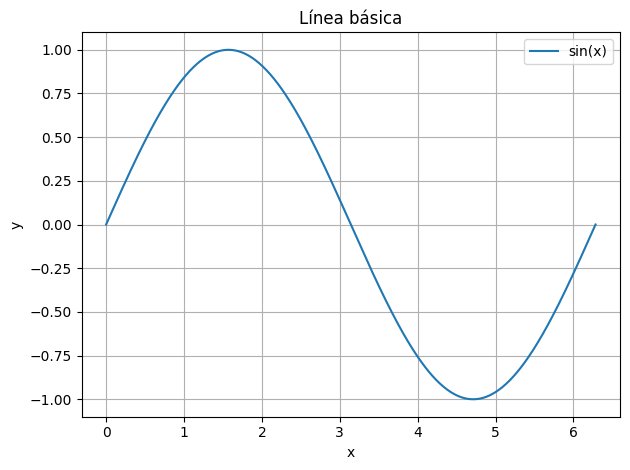

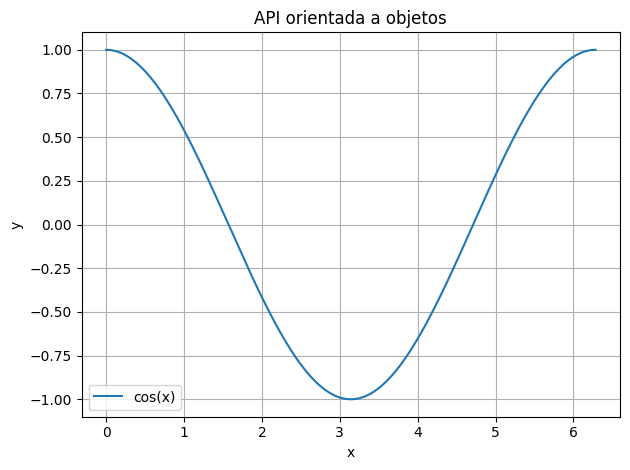

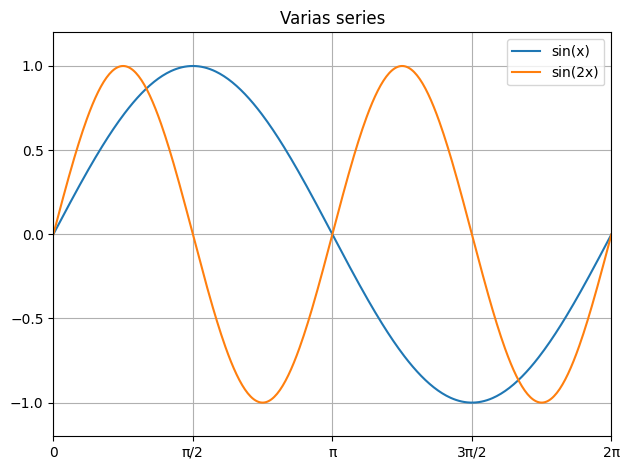

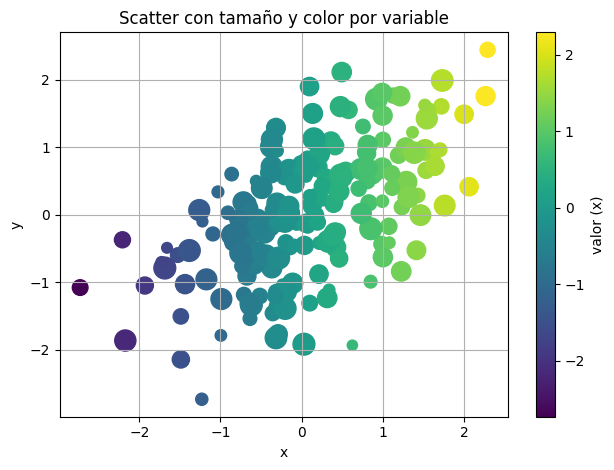

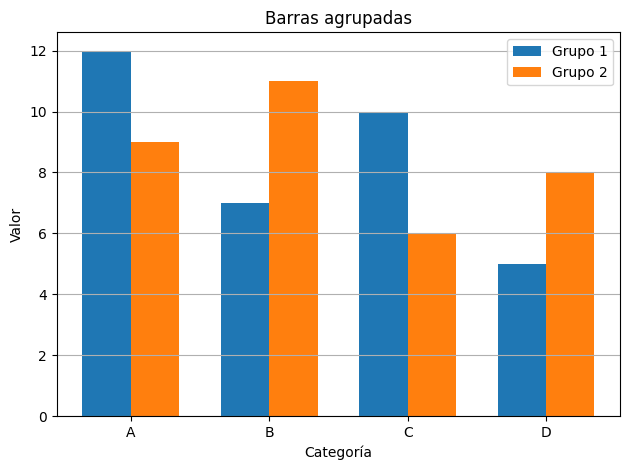

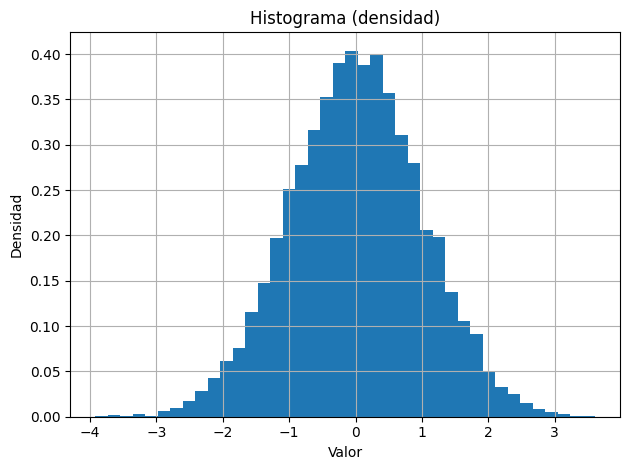

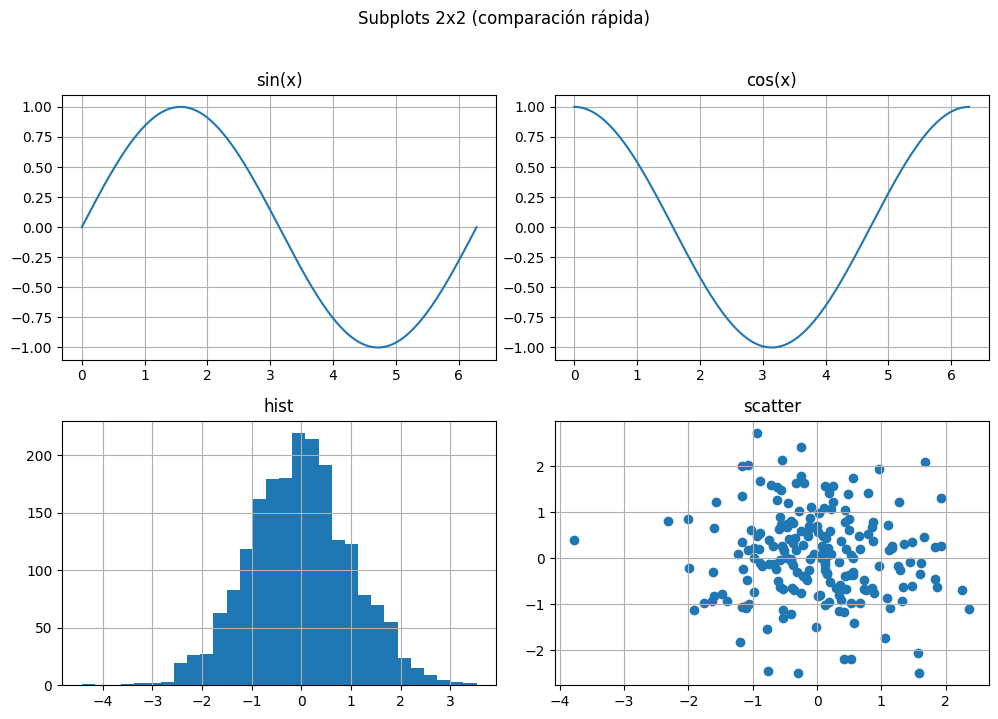

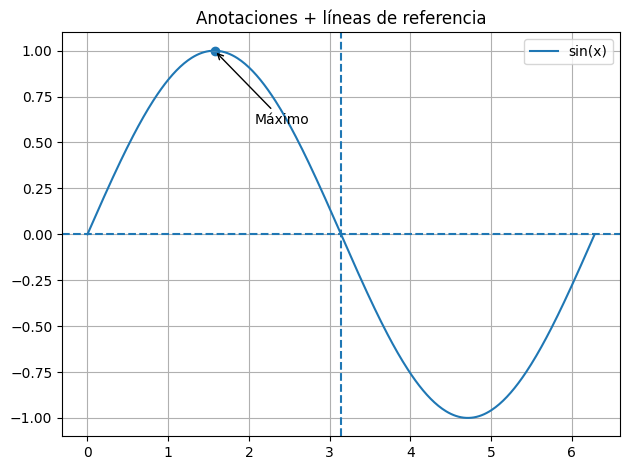

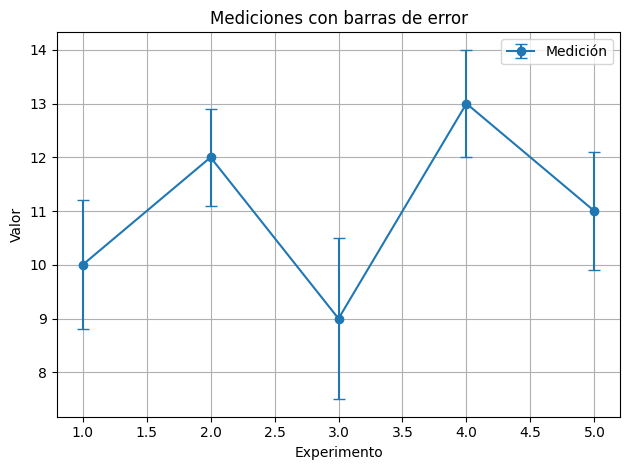

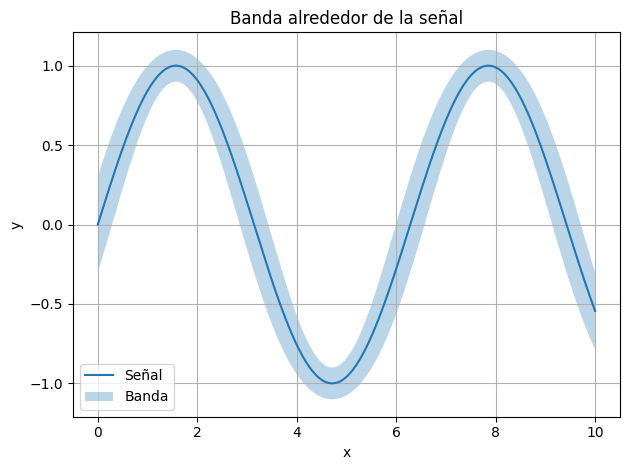

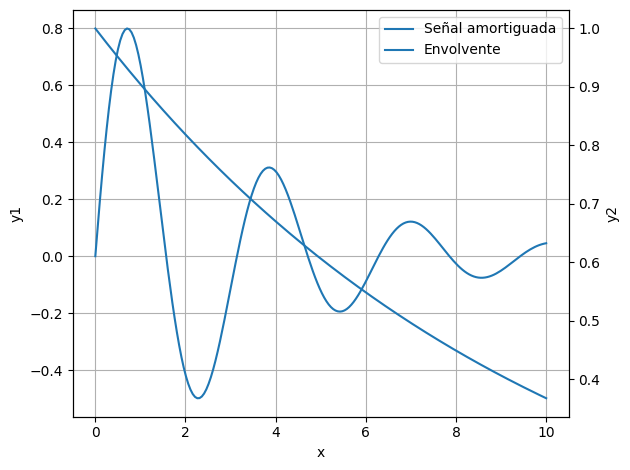

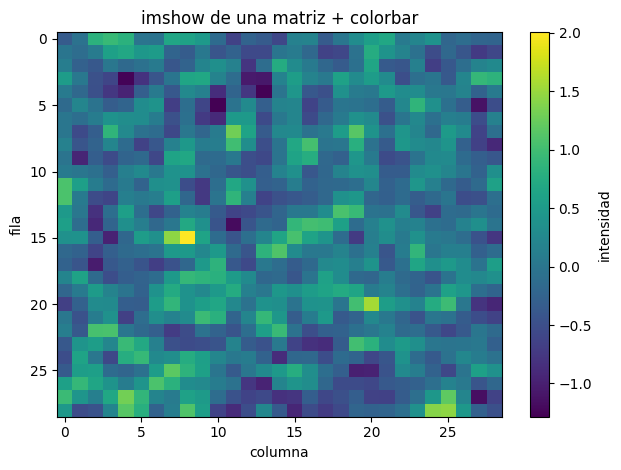

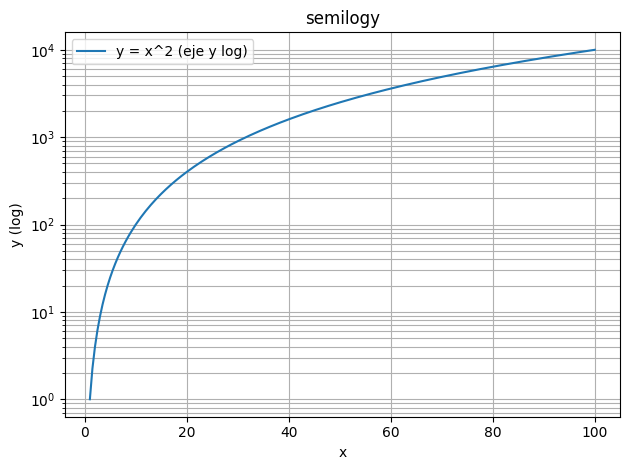

Guardado: figura_exportada.png (dpi=200)


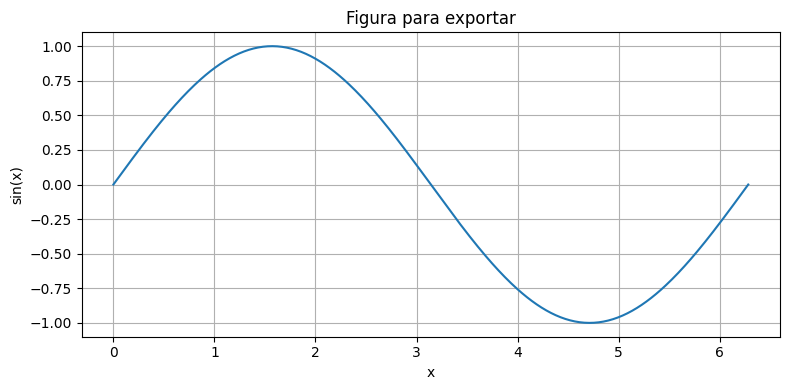

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Semilla para reproducibilidad
rng = np.random.default_rng(123)


# -------------------------------------------------------------------------
# 1) Gráfica más básica: línea y mostrar
# -------------------------------------------------------------------------

x = np.linspace(0, 2 * np.pi, 400)
y = np.sin(x)

plt.figure()  # crea una figura nueva (estilo pyplot)
plt.plot(x, y, label="sin(x)")
plt.title("Línea básica")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 2) API orientada a objetos (fig, ax): recomendado
# -------------------------------------------------------------------------

fig, ax = plt.subplots()
ax.plot(x, np.cos(x), label="cos(x)")
ax.set_title("API orientada a objetos")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 3) Múltiples series + estilos + límites + ticks
# -------------------------------------------------------------------------

y1 = np.sin(x)
y2 = np.sin(2 * x)

fig, ax = plt.subplots()
ax.plot(x, y1, label="sin(x)")
ax.plot(x, y2, label="sin(2x)")
ax.set_title("Varias series")
ax.set_xlim(0, 2 * np.pi)
ax.set_ylim(-1.2, 1.2)

# Ticks personalizados (ejemplo útil en trigonometría)
ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
ax.set_xticklabels(["0", "π/2", "π", "3π/2", "2π"])
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 4) Scatter (dispersión) + tamaño/color por valores
# -------------------------------------------------------------------------

n = 200
xs = rng.normal(size=n)
ys = 0.6 * xs + rng.normal(scale=0.7, size=n)
sizes = 50 + 200 * rng.random(n)
colors = xs  # colorear por xs

fig, ax = plt.subplots()
sc = ax.scatter(xs, ys, s=sizes, c=colors)  # cmap por defecto
ax.set_title("Scatter con tamaño y color por variable")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)
fig.colorbar(sc, ax=ax, label="valor (x)")
fig.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 5) Barras: categorías (bar) y comparación
# -------------------------------------------------------------------------

cats = ["A", "B", "C", "D"]
v1 = np.array([12, 7, 10, 5])
v2 = np.array([9, 11, 6, 8])

idx = np.arange(len(cats))
width = 0.35

fig, ax = plt.subplots()
ax.bar(idx - width / 2, v1, width, label="Grupo 1")
ax.bar(idx + width / 2, v2, width, label="Grupo 2")
ax.set_title("Barras agrupadas")
ax.set_xlabel("Categoría")
ax.set_ylabel("Valor")
ax.set_xticks(idx)
ax.set_xticklabels(cats)
ax.legend()
ax.grid(True, axis="y")  # grid sólo en eje y
fig.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 6) Histograma: distribución y bins
# -------------------------------------------------------------------------

data = rng.normal(loc=0, scale=1, size=10_000)

fig, ax = plt.subplots()
ax.hist(data, bins=40, density=True)  # density=True => área total 1
ax.set_title("Histograma (densidad)")
ax.set_xlabel("Valor")
ax.set_ylabel("Densidad")
ax.grid(True)
fig.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 7) Subplots: paneles múltiples (comparación)
# -------------------------------------------------------------------------

fig, axs = plt.subplots(2, 2, figsize=(10, 7))

axs[0, 0].plot(x, np.sin(x))
axs[0, 0].set_title("sin(x)")

axs[0, 1].plot(x, np.cos(x))
axs[0, 1].set_title("cos(x)")

axs[1, 0].hist(rng.normal(size=2000), bins=30)
axs[1, 0].set_title("hist")

axs[1, 1].scatter(rng.normal(size=200), rng.normal(size=200))
axs[1, 1].set_title("scatter")

for ax in axs.ravel():
  ax.grid(True)

fig.suptitle("Subplots 2x2 (comparación rápida)", y=1.02)
fig.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 8) Anotaciones: etiquetas, flechas, líneas de referencia
# -------------------------------------------------------------------------

y = np.sin(x)
i_max = np.argmax(y)
x_max, y_max = x[i_max], y[i_max]

fig, ax = plt.subplots()
ax.plot(x, y, label="sin(x)")
ax.axhline(0, linestyle="--")  # línea horizontal en y=0
ax.axvline(np.pi, linestyle="--")  # línea vertical en x=pi

ax.scatter([x_max], [y_max])
ax.annotate(
  "Máximo",
  xy=(x_max, y_max),
  xytext=(x_max + 0.5, y_max - 0.4),
  arrowprops=dict(arrowstyle="->"),
)

ax.set_title("Anotaciones + líneas de referencia")
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 9) Error bars: mediciones con incertidumbre
# -------------------------------------------------------------------------

x_m = np.arange(1, 6)
y_m = np.array([10, 12, 9, 13, 11])
err = np.array([1.2, 0.9, 1.5, 1.0, 1.1])

fig, ax = plt.subplots()
ax.errorbar(x_m, y_m, yerr=err, fmt="o-", capsize=4, label="Medición")
ax.set_title("Mediciones con barras de error")
ax.set_xlabel("Experimento")
ax.set_ylabel("Valor")
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 10) fill_between: bandas, intervalos, áreas
# -------------------------------------------------------------------------

x = np.linspace(0, 10, 300)
y = np.sin(x)
band = 0.2 + 0.1 * np.cos(2 * x)

fig, ax = plt.subplots()
ax.plot(x, y, label="Señal")
ax.fill_between(x, y - band, y + band, alpha=0.3, label="Banda")
ax.set_title("Banda alrededor de la señal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 11) Eje secundario (twinx): dos escalas en la misma gráfica
# -------------------------------------------------------------------------

x = np.linspace(0, 10, 200)
y1 = np.exp(-0.3 * x) * np.sin(2 * x)
y2 = np.exp(-0.1 * x)

fig, ax1 = plt.subplots()
ax1.plot(x, y1, label="Señal amortiguada")
ax1.set_xlabel("x")
ax1.set_ylabel("y1")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(x, y2, label="Envolvente")
ax2.set_ylabel("y2")

# Truco: combinar leyendas de ambos ejes
lines = ax1.get_lines() + ax2.get_lines()
labels = [ln.get_label() for ln in lines]
ax1.legend(lines, labels, loc="upper right")

fig.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 12) Imágenes / matrices: imshow + colorbar (heatmap)
# -------------------------------------------------------------------------

Z = rng.normal(size=(30, 30))
# Suavizado simple tipo “filtro”: promedio local (ejemplo conceptual)
# (Para no usar SciPy, hacemos una operación sencilla)
Z2 = (Z[:-1, :-1] + Z[1:, :-1] + Z[:-1, 1:] + Z[1:, 1:]) / 4

fig, ax = plt.subplots()
im = ax.imshow(Z2, aspect="auto")  # mapa de calor
ax.set_title("imshow de una matriz + colorbar")
ax.set_xlabel("columna")
ax.set_ylabel("fila")
fig.colorbar(im, ax=ax, label="intensidad")
fig.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 13) Escalas logarítmicas (semilogy, loglog)
# -------------------------------------------------------------------------

x = np.linspace(1, 100, 200)
y = x ** 2

fig, ax = plt.subplots()
ax.semilogy(x, y, label="y = x^2 (eje y log)")
ax.set_title("semilogy")
ax.set_xlabel("x")
ax.set_ylabel("y (log)")
ax.grid(True, which="both")  # grid mayor y menor
ax.legend()
fig.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 14) Guardar figura (export) y buenas prácticas
# -------------------------------------------------------------------------

x = np.linspace(0, 2 * np.pi, 400)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y)
ax.set_title("Figura para exportar")
ax.set_xlabel("x")
ax.set_ylabel("sin(x)")
ax.grid(True)
fig.tight_layout()

# Guarda en el directorio actual
fig.savefig("figura_exportada.png", dpi=200)
print("Guardado: figura_exportada.png (dpi=200)")

plt.show()
